# Task 3 - Human Audit only (CycleGAN + DiffAugment + EMA, epoch 85)

Runs **only** what the human audit needs, using `generators_epoch_085.pt`. No training.

1. Mount Drive and set paths
2. Rebuild the same validation split (seed 5775) used in training
3. Build the generator and load the EMA weights
4. Generate 30 + 30 evaluation images
5. Create the human-audit rating sheet and image grids for raters
6. After raters fill the CSV, compute mean scores, agreement and Cohen's kappa

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Setup and paths
Edit `TASK3_DIR` / `CHECKPOINT_PATH` if your Drive layout differs.

In [2]:
import random, json, logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image
from tqdm.auto import tqdm

SEED = 5775
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Drive paths -------------------------------------------------
TASK3_DIR = Path("/content/drive/MyDrive/DATA_266_Lab-1/Task-3")
DATA_DIR = TASK3_DIR / "Dataset"
CHECKPOINT_PATH = TASK3_DIR / "checkpoints" / "generators_epoch_085.pt"

# Everything produced here is saved to Drive so it survives the session
RESULTS_DIR = TASK3_DIR / "outputs" / "human_audit_run"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DOMAIN_A_DIR = DATA_DIR / "photo_jpg"   # A = photo
DOMAIN_B_DIR = DATA_DIR / "monet_jpg"   # B = Monet

for p in [DOMAIN_A_DIR, DOMAIN_B_DIR, CHECKPOINT_PATH]:
    assert p.exists(), f"Not found: {p}"

# bf16 autocast like training, but only on GPUs that support it (L4/A100).
# On a T4 this runs in fp32, which is fine for 60 images.
USE_AMP = device.type == "cuda" and torch.cuda.is_bf16_supported()
AMP_DTYPE = torch.bfloat16

logger = logging.getLogger("human_audit")
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())

print("Device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")
print("AMP (bf16):", USE_AMP)

Device: cuda Tesla T4
AMP (bf16): True


### 2. Rebuild the same validation split
Same sorting, seeds and 10% fraction as training, so `val_a_paths` / `val_b_paths` match the original run.

In [3]:
IMAGE_SIZE = 256
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
VALIDATION_FRACTION = 0.10

def find_images(folder):
    paths = sorted(p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)
    if not paths:
        raise ValueError(f"No images found in: {folder}")
    return paths

def split_image_paths(image_paths, validation_fraction, seed):
    paths = list(image_paths)
    random.Random(seed).shuffle(paths)
    validation_size = max(1, int(len(paths) * validation_fraction))
    return paths[validation_size:], paths[:validation_size]

all_a_paths = find_images(DOMAIN_A_DIR)
all_b_paths = find_images(DOMAIN_B_DIR)
print("Total photos:", len(all_a_paths), "| Total Monet:", len(all_b_paths))
assert len(all_a_paths) == 7038 and len(all_b_paths) == 300, "Dataset counts differ from training"

train_a_paths, val_a_paths = split_image_paths(all_a_paths, VALIDATION_FRACTION, SEED)
train_b_paths, val_b_paths = split_image_paths(all_b_paths, VALIDATION_FRACTION, SEED + 1)
print("Validation photos:", len(val_a_paths), "| Validation Monet:", len(val_b_paths))

validation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

Total photos: 7038 | Total Monet: 300
Validation photos: 703 | Validation Monet: 30


### 3. Generator and checkpoint
The checkpoint stores the **EMA** weights under `G_AB_state_dict` / `G_BA_state_dict`.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, num_residual_blocks=9):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(input_channels, 64, kernel_size=7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        ]
        channels = 64
        for _ in range(2):
            layers += [
                nn.Conv2d(channels, channels * 2, kernel_size=4, stride=2, padding=1),
                nn.InstanceNorm2d(channels * 2),
                nn.ReLU(inplace=True),
            ]
            channels *= 2
        for _ in range(num_residual_blocks):
            layers.append(ResidualBlock(channels))
        for _ in range(2):
            layers += [
                nn.ConvTranspose2d(channels, channels // 2, kernel_size=4, stride=2, padding=1),
                nn.InstanceNorm2d(channels // 2),
                nn.ReLU(inplace=True),
            ]
            channels //= 2
        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(channels, output_channels, kernel_size=7),
            nn.Tanh(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


G_AB = Generator().to(device)   # photo -> Monet
G_BA = Generator().to(device)   # Monet -> photo

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
G_AB.load_state_dict(checkpoint["G_AB_state_dict"])
G_BA.load_state_dict(checkpoint["G_BA_state_dict"])
G_AB.eval(); G_BA.eval()

print("Loaded epoch:", checkpoint["epoch"],
      "| uses_ema:", checkpoint.get("uses_ema"),
      "|", checkpoint.get("metric_name"), "=", checkpoint.get("metric_value"))
del checkpoint

Loaded epoch: 85 | uses_ema: True | ema_validation_cycle_loss = 0.07205851351221403


### 4. Generate evaluation images (30 per direction)

In [5]:
EVALUATION_IMAGE_COUNT = 30
EVALUATION_DIR = RESULTS_DIR / "evaluation_images"
EVALUATION_FOLDERS = {
    name: EVALUATION_DIR / name
    for name in ["real_A", "fake_A", "reconstructed_A", "real_B", "fake_B", "reconstructed_B"]
}
for folder in EVALUATION_FOLDERS.values():
    folder.mkdir(parents=True, exist_ok=True)


class SingleDomainDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        path = self.image_paths[index]
        return {"image": self.transform(Image.open(path).convert("RGB")), "path": str(path)}


def save_tensor_image(image_tensor, output_path):
    image = (image_tensor.detach().float().cpu() * 0.5 + 0.5).clamp(0, 1)
    to_pil_image(image).save(output_path)


@torch.no_grad()
def translate_folder(paths, forward_gen, backward_gen, real_key, fake_key, recon_key, desc):
    loader = DataLoader(SingleDomainDataset(paths, validation_transform), batch_size=1, shuffle=False)
    for index, batch in enumerate(tqdm(loader, desc=desc)):
        real = batch["image"].to(device)
        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            fake = forward_gen(real)
            recon = backward_gen(fake)
        filename = f"{index:05d}.png"
        save_tensor_image(real[0], EVALUATION_FOLDERS[real_key] / filename)
        save_tensor_image(fake[0], EVALUATION_FOLDERS[fake_key] / filename)
        save_tensor_image(recon[0], EVALUATION_FOLDERS[recon_key] / filename)


n = min(EVALUATION_IMAGE_COUNT, len(val_a_paths), len(val_b_paths))
translate_folder(val_a_paths[:n], G_AB, G_BA, "real_A", "fake_B", "reconstructed_A", "Photo -> Monet")
translate_folder(val_b_paths[:n], G_BA, G_AB, "real_B", "fake_A", "reconstructed_B", "Monet -> Photo")

for name, folder in EVALUATION_FOLDERS.items():
    print(name, len(list(folder.glob("*.png"))))

Photo -> Monet:   0%|          | 0/30 [00:00<?, ?it/s]

Monet -> Photo:   0%|          | 0/30 [00:00<?, ?it/s]

real_A 30
fake_A 30
reconstructed_A 30
real_B 30
fake_B 30
reconstructed_B 30


### 5. Human audit: create the rating sheet

In [6]:
from sklearn.metrics import cohen_kappa_score

HUMAN_AUDIT_DIR = RESULTS_DIR / "human_audit"
HUMAN_AUDIT_DIR.mkdir(parents=True, exist_ok=True)
HUMAN_AUDIT_TEMPLATE = HUMAN_AUDIT_DIR / "human_audit_scores.csv"
RATING_COLUMNS = [
    "rater_1_style", "rater_1_content", "rater_1_artifact_free",
    "rater_2_style", "rater_2_content", "rater_2_artifact_free",
]
SAMPLES_PER_DIRECTION = 15


def create_human_audit_template():
    rows = []
    directions = [
        ("photo_to_monet", "real_A", "fake_B"),
        ("monet_to_photo", "real_B", "fake_A"),
    ]
    for d, (direction, src_key, gen_key) in enumerate(directions):
        for index in range(SAMPLES_PER_DIRECTION):
            filename = f"{index:05d}.png"
            rows.append({
                "sample_id": f"sample_{d * SAMPLES_PER_DIRECTION + index + 1:02d}",
                "direction": direction,
                "source_image": str(EVALUATION_FOLDERS[src_key] / filename),
                "generated_image": str(EVALUATION_FOLDERS[gen_key] / filename),
                **{col: "" for col in RATING_COLUMNS},
            })
    audit_df = pd.DataFrame(rows)
    audit_df.to_csv(HUMAN_AUDIT_TEMPLATE, index=False)
    logger.info(f"Human-audit template saved to: {HUMAN_AUDIT_TEMPLATE}")
    return audit_df


# Don't overwrite a sheet that already has ratings in it
if HUMAN_AUDIT_TEMPLATE.exists() and pd.read_csv(HUMAN_AUDIT_TEMPLATE)[RATING_COLUMNS].notna().any().any():
    print("Ratings already present, keeping existing sheet:", HUMAN_AUDIT_TEMPLATE)
    human_audit_df = pd.read_csv(HUMAN_AUDIT_TEMPLATE)
else:
    human_audit_df = create_human_audit_template()
display(human_audit_df.head())

Human-audit template saved to: /content/drive/MyDrive/DATA_266_Lab-1/Task-3/outputs/human_audit_run/human_audit/human_audit_scores.csv
INFO:human_audit:Human-audit template saved to: /content/drive/MyDrive/DATA_266_Lab-1/Task-3/outputs/human_audit_run/human_audit/human_audit_scores.csv


,sample_id,direction,source_image,generated_image,rater_1_style,rater_1_content,rater_1_artifact_free,rater_2_style,rater_2_content,rater_2_artifact_free
0,sample_01,photo_to_monet,/content/drive/MyDrive/DATA_266_Lab-1/Task-3/o...,/content/drive/MyDrive/DATA_266_Lab-1/Task-3/o...,,,,,,
1,sample_02,photo_to_monet,/content/drive/MyDrive/DATA_266_Lab-1/Task-3/o...,/content/drive/MyDrive/DATA_266_Lab-1/Task-3/o...,,,,,,
2,sample_03,photo_to_monet,/content/drive/MyDrive/DATA_266_Lab-1/Task-3/o...,/content/drive/MyDrive/DATA_266_Lab-1/Task-3/o...,,,,,,
3,sample_04,photo_to_monet,/content/drive/MyDrive/DATA_266_Lab-1/Task-3/o...,/content/drive/MyDrive/DATA_266_Lab-1/Task-3/o...,,,,,,
4,sample_05,photo_to_monet,/content/drive/MyDrive/DATA_266_Lab-1/Task-3/o...,/content/drive/MyDrive/DATA_266_Lab-1/Task-3/o...,,,,,,


### 5b. Show the 30 source/generated pairs for the raters
Also saved as `rating_sheet_*.png` in the human_audit folder so raters can view them outside Colab.

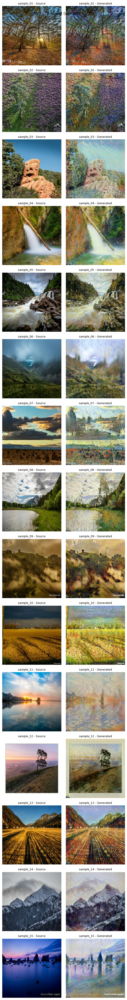

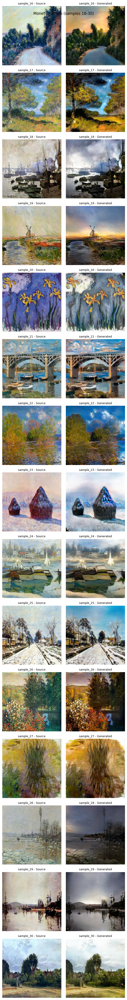

In [7]:
import matplotlib.pyplot as plt

def show_pairs(direction, title):
    subset = human_audit_df[human_audit_df["direction"] == direction].reset_index(drop=True)
    fig, axes = plt.subplots(len(subset), 2, figsize=(6, 3 * len(subset)))
    for i, row in subset.iterrows():
        for j, (col, label) in enumerate([("source_image", "Source"), ("generated_image", "Generated")]):
            axes[i, j].imshow(Image.open(row[col]))
            axes[i, j].set_title(f"{row['sample_id']} - {label}", fontsize=9)
            axes[i, j].axis("off")
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    fig.savefig(HUMAN_AUDIT_DIR / f"rating_sheet_{direction}.png", dpi=100, bbox_inches="tight")
    plt.show()

show_pairs("photo_to_monet", "Photo -> Monet (samples 01-15)")
show_pairs("monet_to_photo", "Monet -> Photo (samples 16-30)")

### 6. Fill in the ratings, then compute results

Open `human_audit_scores.csv` in Drive (`Task-3/outputs/human_audit_run/human_audit/`), e.g. with Google Sheets.
Each rater gives a **1-5** score per sample for `style`, `content` and `artifact_free`.
Download it as CSV, put it back at the same path with the same name, then run the cell below.

In [11]:
def calculate_human_audit_results():
    audit_df = pd.read_csv(HUMAN_AUDIT_TEMPLATE)

    if audit_df[RATING_COLUMNS].isna().any().any():
        raise ValueError("The human-audit sheet contains missing ratings.")
    if not audit_df[RATING_COLUMNS].apply(lambda c: c.between(1, 5)).all().all():
        raise ValueError("Every human-audit score must be between 1 and 5.")

    results = {}
    all_r1, all_r2 = [], []
    for criterion in ["style", "content", "artifact_free"]:
        r1 = audit_df[f"rater_1_{criterion}"].astype(int)
        r2 = audit_df[f"rater_2_{criterion}"].astype(int)
        results[criterion] = {
            "mean_score": float((r1.mean() + r2.mean()) / 2),
            "exact_agreement": float((r1 == r2).mean()),
            "weighted_cohens_kappa": float(cohen_kappa_score(r1, r2, weights="quadratic")),
        }
        all_r1.extend(r1.tolist()); all_r2.extend(r2.tolist())

    results["overall"] = {
        "mean_human_score": float(audit_df[RATING_COLUMNS].to_numpy().mean()),
        "exact_agreement": float(np.mean(np.array(all_r1) == np.array(all_r2))),
        "weighted_cohens_kappa": float(cohen_kappa_score(all_r1, all_r2, weights="quadratic")),
        "number_of_samples": len(audit_df),
        "number_of_raters": 2,
    }

    output_path = HUMAN_AUDIT_DIR / "human_audit_results.json"
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=4)
    logger.info(f"Human-audit results saved to: {output_path}")
    return results


human_audit_results = calculate_human_audit_results()
print(json.dumps(human_audit_results, indent=4))

Human-audit results saved to: /content/drive/MyDrive/DATA_266_Lab-1/Task-3/outputs/human_audit_run/human_audit/human_audit_results.json
INFO:human_audit:Human-audit results saved to: /content/drive/MyDrive/DATA_266_Lab-1/Task-3/outputs/human_audit_run/human_audit/human_audit_results.json


{
    "style": {
        "mean_score": 2.95,
        "exact_agreement": 0.4,
        "weighted_cohens_kappa": 0.6505608283002589
    },
    "content": {
        "mean_score": 2.8666666666666667,
        "exact_agreement": 0.4666666666666667,
        "weighted_cohens_kappa": 0.5867768595041323
    },
    "artifact_free": {
        "mean_score": 2.8166666666666664,
        "exact_agreement": 0.4,
        "weighted_cohens_kappa": 0.57002457002457
    },
    "overall": {
        "mean_human_score": 2.8777777777777778,
        "exact_agreement": 0.4222222222222222,
        "weighted_cohens_kappa": 0.5997679814385151,
        "number_of_samples": 30,
        "number_of_raters": 2
    }
}
